<a href="https://colab.research.google.com/github/SaddyPineda/hands-on-ml/blob/main/chapter_02/chapter02_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-learn matplotlib pandas numpy openpyxl

import sklearn, pandas as pd, numpy as np, matplotlib.pyplot as plt
print("Ready for Chapter 2!")

Ready for Chapter 2!


Get the data → Explore & visualize → Clean & prepare →
Select a model → Train it → Evaluate it

In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(df.shape)
print(df.head())

(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [3]:
# Basic stats — like summary() in R
print(df.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

In [4]:
# Check for missing values — critical before any ML
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


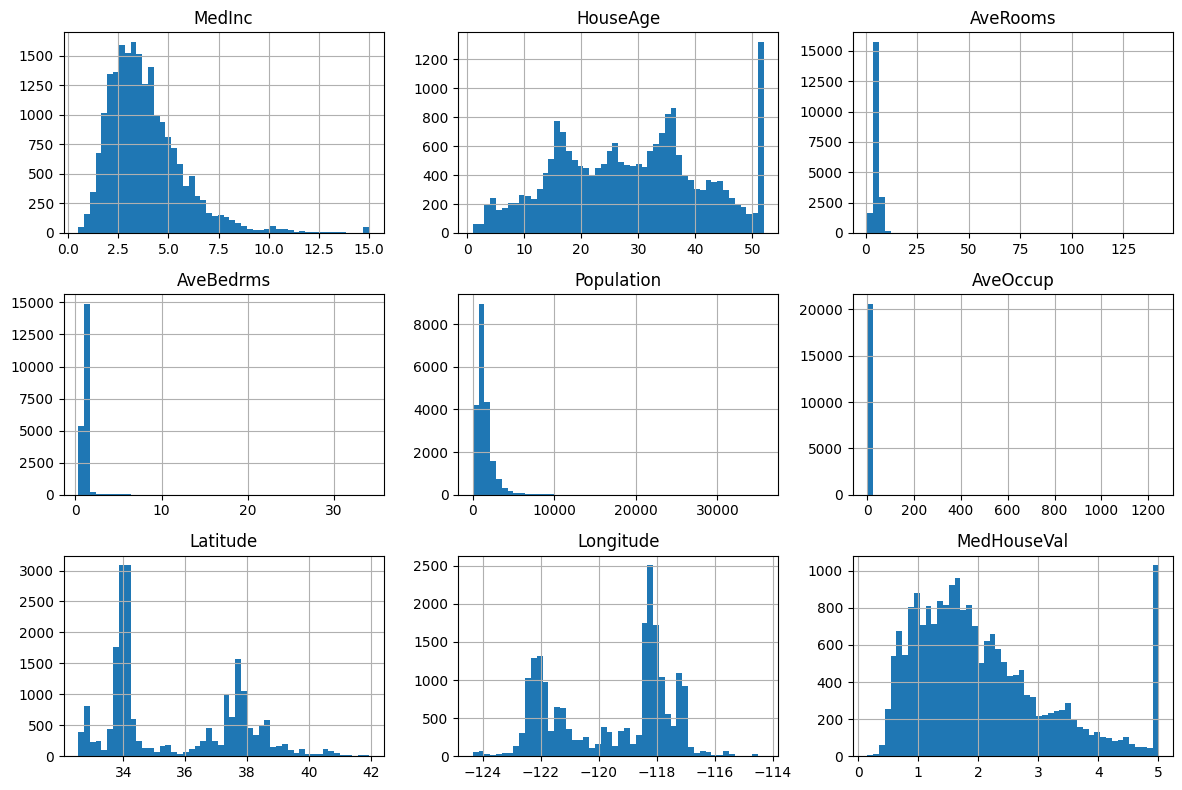

In [5]:
# Visualize distributions — like hist() in R
df.hist(bins=50, figsize=(12, 8))
plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

print(f"Training set: {len(train_set)} rows")
print(f"Test set:     {len(test_set)} rows")

Training set: 16512 rows
Test set:     4128 rows


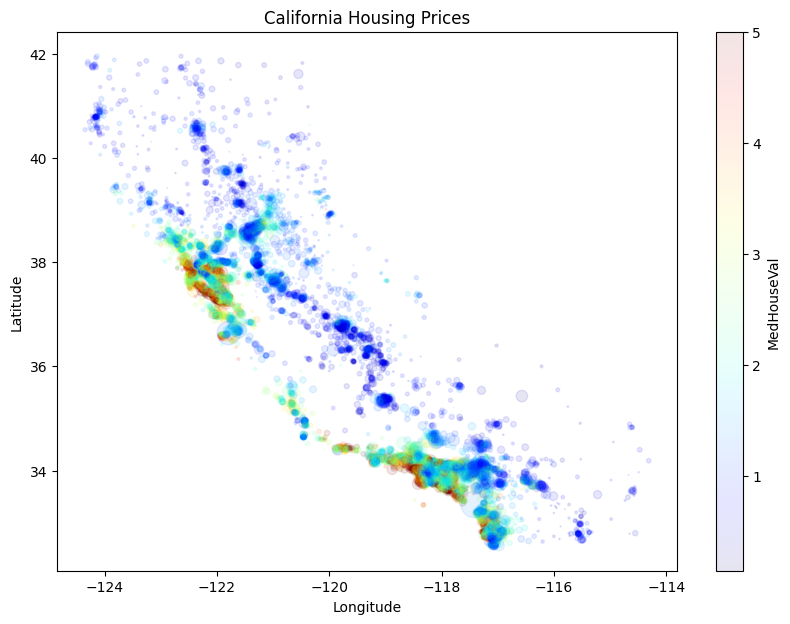

In [7]:
train_set.plot(kind="scatter", x="Longitude", y="Latitude",
               alpha=0.1, figsize=(10, 7),
               c="MedHouseVal", cmap="jet", colorbar=True,
               s=train_set["Population"]/100)
plt.title("California Housing Prices")
plt.show()

In [8]:
corr_matrix = train_set.corr(numeric_only=True)
print(corr_matrix["MedHouseVal"].sort_values(ascending=False))

MedHouseVal    1.000000
MedInc         0.690647
AveRooms       0.158485
HouseAge       0.103706
AveOccup      -0.022030
Population    -0.026032
Longitude     -0.046349
AveBedrms     -0.051351
Latitude      -0.142983
Name: MedHouseVal, dtype: float64


In [9]:
# Separate features (X) and target (y) — standard ML convention
X_train = train_set.drop("MedHouseVal", axis=1)
y_train = train_set["MedHouseVal"]

X_test = test_set.drop("MedHouseVal", axis=1)
y_test = test_set["MedHouseVal"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (16512, 8)
y_train shape: (16512,)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # note: only transform, never fit on test data

print("Scaling done. Mean ~0:", X_train_scaled.mean(axis=0).round(2))

Scaling done. Mean ~0: [-0. -0. -0. -0. -0.  0.  0.  0.]


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

# Train all three
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree":     DecisionTreeRegressor(random_state=42),
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_train_scaled)
    rmse = root_mean_squared_error(y_train, preds)
    print(f"{name:25s} RMSE: {rmse:.4f}")

Linear Regression         RMSE: 0.7197
Decision Tree             RMSE: 0.0000
Random Forest             RMSE: 0.1880


In [12]:
from sklearn.model_selection import cross_val_score
import numpy as np

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train,
                             scoring="neg_root_mean_squared_error", cv=5)
    rmse_scores = -scores
    print(f"{name:25s} CV RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")

Linear Regression         CV RMSE: 0.7205 ± 0.0103
Decision Tree             CV RMSE: 0.7242 ± 0.0198
Random Forest             CV RMSE: 0.5115 ± 0.0044


In [13]:
# Final evaluation on test set — you only do this ONCE
rf_model = models["Random Forest"]
y_pred = rf_model.predict(X_test_scaled)
test_rmse = root_mean_squared_error(y_test, y_pred)
print(f"Final Test RMSE: {test_rmse:.4f}")

# What does this error mean in dollars?
print(f"Average prediction error: ${test_rmse * 100_000:,.0f}")

Final Test RMSE: 0.5051
Average prediction error: $50,514


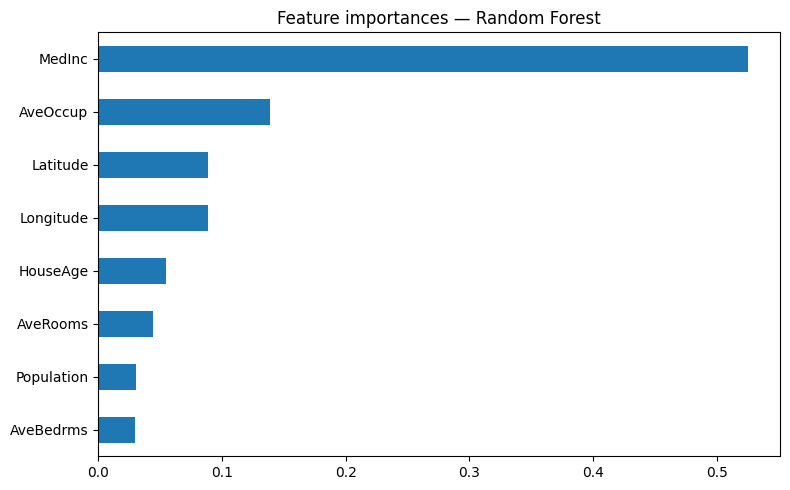

In [14]:
feature_names = X_train.columns
importances = rf_model.feature_importances_

feat_importance = pd.Series(importances, index=feature_names)
feat_importance.sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Feature importances — Random Forest")
plt.tight_layout()
plt.show()